In [ ]:
from google.colab import files
uploaded = files.upload()

Saving processed.cleveland.data to processed.cleveland.data
Saving processed.hungarian.data to processed.hungarian.data
Saving processed.switzerland.data to processed.switzerland.data
Saving processed.va.data to processed.va.data


In [ ]:
import pandas as pd
import numpy as np

col_names = ['age','sex','cp','trestbps','chol','fbs',
             'restecg','thalach','exang','oldpeak',
             'slope','ca','thal','target']

df1 = pd.read_csv('processed.cleveland.data', names=col_names, na_values='?')
df2 = pd.read_csv('processed.hungarian.data', names=col_names, na_values='?')
df3 = pd.read_csv('processed.switzerland.data', names=col_names, na_values='?')
df4 = pd.read_csv('processed.va.data', names=col_names, na_values='?')

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print("Jumlah data:", df.shape)
df.head()

Jumlah data: (920, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
print("=== INFO DATASET ===")
print(df.info())
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== DATA DUPLIKAT ===")
print("Jumlah duplikat:", df.duplicated().sum())
print("\n=== DISTRIBUSI TARGET ===")
print(df['target'].value_counts())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 100.8 KB
None

=== MISSING VALUES ===
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope   

In [ ]:
# Hapus duplikat
df = df.drop_duplicates()
print("Setelah hapus duplikat:", df.shape)

# Isi missing value dengan median
df = df.fillna(df.median())
print("Missing values setelah diisi:", df.isnull().sum().sum())

Setelah hapus duplikat: (918, 14)
Missing values setelah diisi: 0


In [ ]:
# Ubah target jadi biner (0=tidak sakit, 1=sakit)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print("Distribusi target setelah encoding:")
print(df['target'].value_counts())

Distribusi target setelah encoding:
target
1    508
0    410
Name: count, dtype: int64


In [ ]:
X = df.drop('target', axis=1)
y = df['target']
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (918, 13)
Shape y: (918,)


In [ ]:
from imblearn.over_sampling import SMOTE

# SMOTE tanpa normalisasi dulu
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Setelah SMOTE:", X_resampled.shape)
print("Distribusi target:")
print(pd.Series(y_resampled).value_counts())

Setelah SMOTE: (1016, 13)
Distribusi target:
target
0    508
1    508
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print("Data train:", X_train.shape)
print("Data test:", X_test.shape)

Data train: (812, 13)
Data test: (204, 13)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

print("Training Decision Tree dengan Pipeline...")

# Pipeline: Normalisasi + Model
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=5,
                       scoring='accuracy', n_jobs=-1, verbose=1)
grid_dt.fit(X_train, y_train)

print("\nParameter terbaik DT:", grid_dt.best_params_)
print("Akurasi CV DT:", round(grid_dt.best_score_ * 100, 2), "%")

Training Decision Tree dengan Pipeline...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Parameter terbaik DT: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Akurasi CV DT: 78.21 %


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("\nTraining KNN dengan Pipeline...")

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5,
                        scoring='accuracy', n_jobs=-1, verbose=1)
grid_knn.fit(X_train, y_train)

print("\nParameter terbaik KNN:", grid_knn.best_params_)
print("Akurasi CV KNN:", round(grid_knn.best_score_ * 100, 2), "%")


Training KNN dengan Pipeline...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Parameter terbaik KNN: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
Akurasi CV KNN: 83.63 %


In [ ]:
from sklearn.naive_bayes import GaussianNB

print("\nTraining Naive Bayes dengan Pipeline...")

pipeline_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GaussianNB())
])

param_grid_nb = {
    'classifier__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_nb = GridSearchCV(pipeline_nb, param_grid_nb, cv=5,
                       scoring='accuracy', n_jobs=-1, verbose=1)
grid_nb.fit(X_train, y_train)

print("\nParameter terbaik NB:", grid_nb.best_params_)
print("Akurasi CV NB:", round(grid_nb.best_score_ * 100, 2), "%")


Training Naive Bayes dengan Pipeline...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Parameter terbaik NB: {'classifier__var_smoothing': 1e-09}
Akurasi CV NB: 81.53 %


In [ ]:
from sklearn.svm import SVC

print("\nTraining SVM dengan Pipeline...")

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(probability=True, random_state=42))
])

param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(pipeline_svm, param_grid_svm, cv=5,
                        scoring='accuracy', n_jobs=-1, verbose=1)
grid_svm.fit(X_train, y_train)

print("\nParameter terbaik SVM:", grid_svm.best_params_)
print("Akurasi CV SVM:", round(grid_svm.best_score_ * 100, 2), "%")


Training SVM dengan Pipeline...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Parameter terbaik SVM: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Akurasi CV SVM: 82.76 %


In [ ]:
from sklearn.neural_network import MLPClassifier

print("\nTraining ANN dengan Pipeline...")

pipeline_ann = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(max_iter=1000, random_state=42))
])

param_grid_ann = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001]
}

grid_ann = GridSearchCV(pipeline_ann, param_grid_ann, cv=5,
                        scoring='accuracy', n_jobs=-1, verbose=1)
grid_ann.fit(X_train, y_train)

print("\nParameter terbaik ANN:", grid_ann.best_params_)
print("Akurasi CV ANN:", round(grid_ann.best_score_ * 100, 2), "%")


Training ANN dengan Pipeline...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Parameter terbaik ANN: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (50,)}
Akurasi CV ANN: 82.27 %


In [ ]:
from sklearn.linear_model import LogisticRegression

print("\nTraining Logistic Regression dengan Pipeline...")

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5,
                       scoring='accuracy', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

print("\nParameter terbaik LR:", grid_lr.best_params_)
print("Akurasi CV LR:", round(grid_lr.best_score_ * 100, 2), "%")


Training Logistic Regression dengan Pipeline...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Parameter terbaik LR: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}
Akurasi CV LR: 82.51 %


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

models = {
    'Decision Tree': grid_dt.best_estimator_,
    'KNN': grid_knn.best_estimator_,
    'Naive Bayes': grid_nb.best_estimator_,
    'SVM': grid_svm.best_estimator_,
    'ANN': grid_ann.best_estimator_,
    'Logistic Regression': grid_lr.best_estimator_
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    acc_test = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    y_train_pred = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_train_pred)

    results.append({
        'Model': name,
        'Akurasi Test (%)': round(acc_test * 100, 2),
        'Akurasi Train (%)': round(acc_train * 100, 2),
        'Selisih (%)': round(abs(acc_train - acc_test) * 100, 2),
        'F1-Score': round(f1, 4),
        'AUC': round(auc, 4)
    })

df_results = pd.DataFrame(results)
print("\n=== HASIL EVALUASI 6 MODEL DENGAN PIPELINE ===")
print(df_results.to_string(index=False))


=== HASIL EVALUASI 6 MODEL DENGAN PIPELINE ===
              Model  Akurasi Test (%)  Akurasi Train (%)  Selisih (%)  F1-Score    AUC
      Decision Tree             72.55              80.42         7.87    0.7308 0.8164
                KNN             82.35              85.22         2.87    0.8163 0.8793
        Naive Bayes             80.39              83.00         2.61    0.8000 0.8937
                SVM             82.35              88.79         6.44    0.8163 0.9107
                ANN             82.84              94.83        11.98    0.8168 0.8900
Logistic Regression             81.37              82.51         1.14    0.8061 0.8832


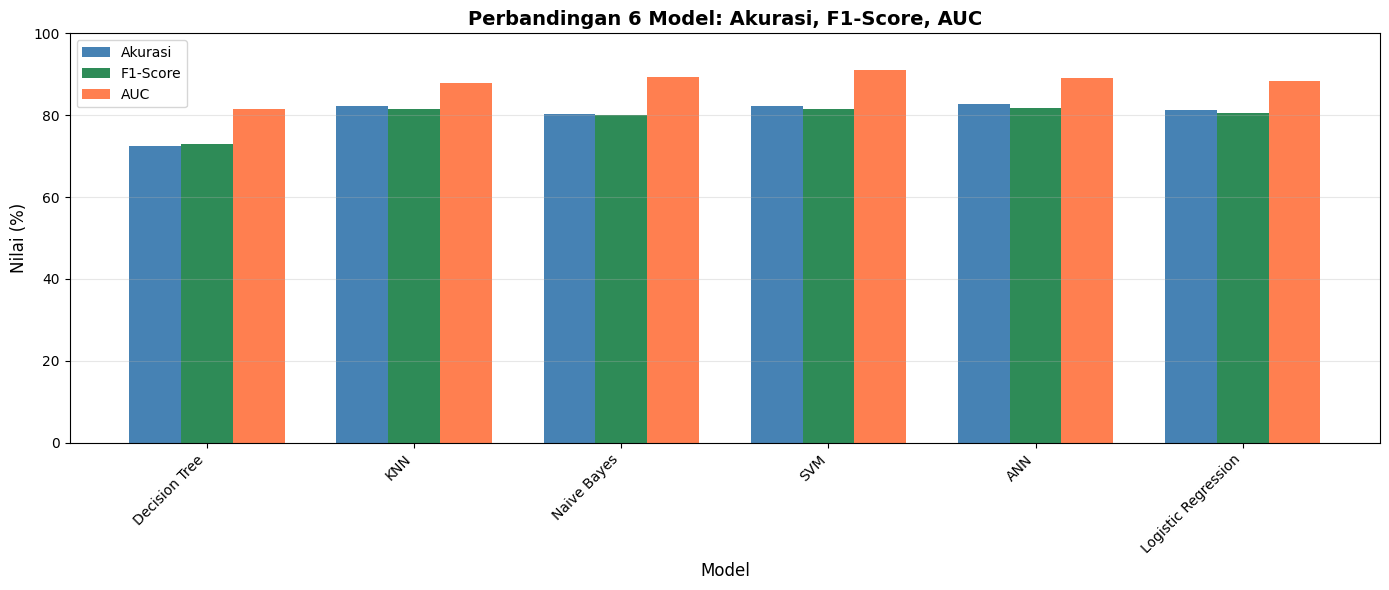

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data untuk visualisasi
models_name = df_results['Model'].tolist()
acc_test = df_results['Akurasi Test (%)'].tolist()
f1_scores = [x * 100 for x in df_results['F1-Score'].tolist()]
auc_scores = [x * 100 for x in df_results['AUC'].tolist()]

x = np.arange(len(models_name))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, acc_test, width, label='Akurasi', color='steelblue')
bars2 = ax.bar(x, f1_scores, width, label='F1-Score', color='seagreen')
bars3 = ax.bar(x + width, auc_scores, width, label='AUC', color='coral')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Nilai (%)', fontsize=12)
ax.set_title('Perbandingan 6 Model: Akurasi, F1-Score, AUC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_name, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_6_model.png', dpi=100, bbox_inches='tight')
plt.show()

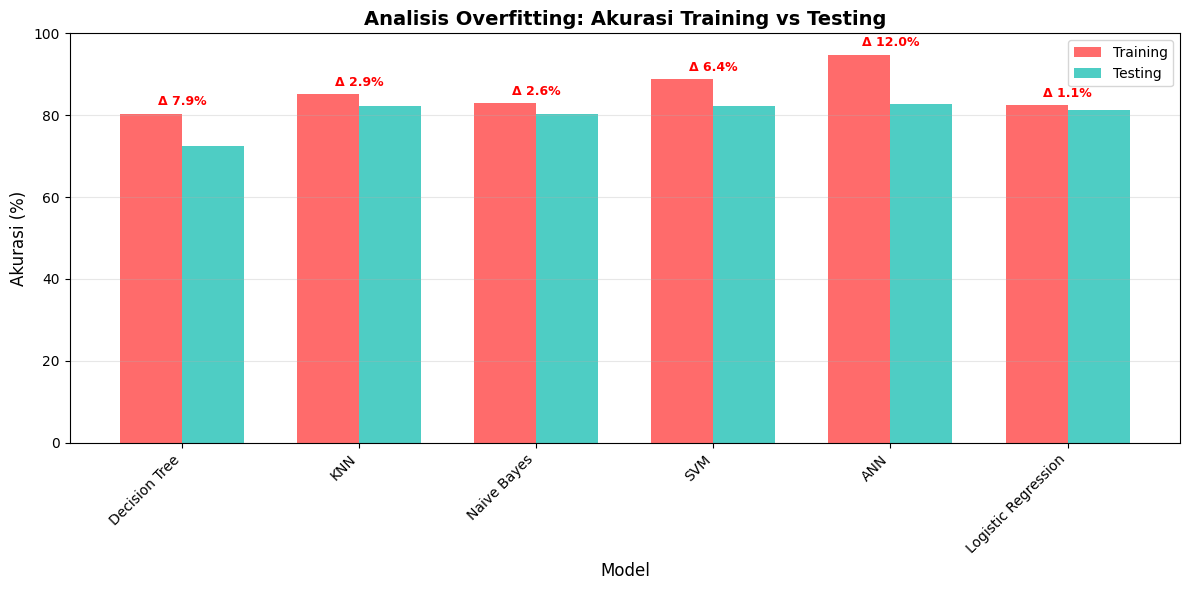

In [ ]:
models_name = df_results['Model'].tolist()
acc_train = df_results['Akurasi Train (%)'].tolist()
acc_test = df_results['Akurasi Test (%)'].tolist()

x = np.arange(len(models_name))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, acc_train, width, label='Training', color='#FF6B6B')
bars2 = ax.bar(x + width/2, acc_test, width, label='Testing', color='#4ECDC4')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Akurasi (%)', fontsize=12)
ax.set_title('Analisis Overfitting: Akurasi Training vs Testing', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_name, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Tambah label selisih
for i, (train, test) in enumerate(zip(acc_train, acc_test)):
    selisih = abs(train - test)
    ax.text(i, max(train, test) + 2, f'Δ {selisih:.1f}%',
            ha='center', fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

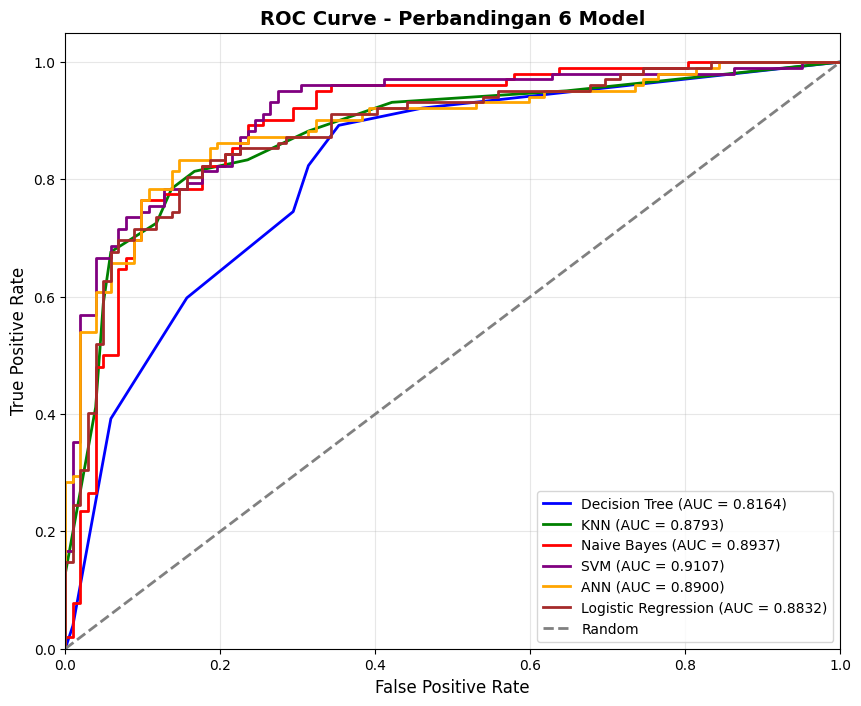

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for (name, model), color in zip(models.items(), colors):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Perbandingan 6 Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.savefig('roc_curve_6_model.png', dpi=100, bbox_inches='tight')
plt.show()

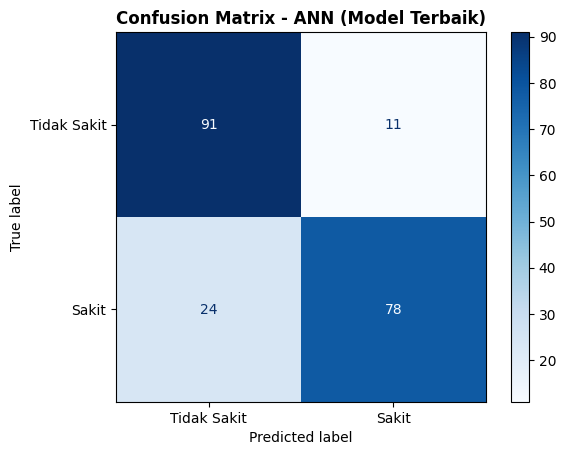

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = grid_ann.best_estimator_
y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
    display_labels=['Tidak Sakit', 'Sakit'],
    cmap='Blues')
plt.title('Confusion Matrix - ANN (Model Terbaik)', fontweight='bold', fontsize=12)
plt.savefig('confusion_matrix_ann.png', dpi=100)
plt.show()